# LSTM 기반 뉴스 텍스트 분류

LSTM 텍스트 분류는 문장을 토큰 순서대로 읽어 문맥을 은닉 상태에 요약하고, 그 요약을 클래스 점수로 변환하는 지도학습 방법이다. 파일명에는 수업 순서를 위해 `rnn`이 남아 있지만, 실제 모델은 기본 `nn.RNN`이 아니라 장기 정보를 더 안정적으로 전달하도록 만든 `nn.LSTM`이다.

단어 빈도만 사용하는 모델은 문장 안의 순서를 직접 표현하지 못한다. LSTM은 앞 토큰의 처리 결과를 다음 토큰으로 전달하므로 순서와 문맥이 중요한 뉴스 주제 분류, 감성 분석과 의도 분류에 사용할 수 있다.

이번 교안은 `Embedding → LSTM → Linear` 모델을 실제로 학습한다. 학습하지 않은 로짓의 shape만 보는 데서 끝나지 않고, 최빈 클래스 기준선과 테스트 macro F1을 비교하며 예측확률과 오분류 문서를 해석한다.

## 01. LSTM이 문장을 분류하는 방법

LSTM은 RNN 계열의 순환 신경망이다. 같은 LSTM 셀을 토큰 위치마다 반복해서 사용하면서 이전 위치의 은닉 상태와 셀 상태를 다음 위치로 전달한다. 여기서 반복되는 것은 계층의 개수가 아니라 문장 안의 토큰 위치이다.

분류 모델은 마지막 위치까지 읽고 남은 은닉 상태를 문장 벡터로 사용한다. 이 벡터 자체는 클래스 확률이 아니며, `nn.Linear`가 클래스 수만큼의 로짓으로 바꾼 뒤 `CrossEntropyLoss`가 정답과 비교한다.

- **토큰 ID**: 어휘 사전에서 단어에 부여한 정수
- **임베딩**: 각 토큰 ID가 가리키는 학습 가능한 실수 벡터
- **은닉 상태**: 현재 위치까지 읽은 순서 정보를 요약한 벡터
- **로짓**: 확률로 변환하기 전의 클래스별 원시 점수
- **macro F1**: 클래스마다 구한 F1을 같은 비중으로 평균한 값


## 02. 토큰 ID가 뉴스 주제 로짓이 되는 흐름

LSTM 분류기는 정수 토큰 ID를 임베딩 벡터로 바꾸고 토큰 순서를 따라 읽는다. 마지막 은닉 상태는 문장 전체를 요약한 벡터이며, 선형 계층이 이를 세 뉴스 주제의 로짓으로 변환한다.

`B`는 한 배치의 문장 수, `L`은 패딩된 토큰 위치 수, `E`는 토큰 임베딩 차원, `H`는 은닉 상태 차원이다. 마지막 `(B, 3)`의 각 행은 한 문장에 대한 세 클래스 점수이다. 로짓의 열 순서는 데이터의 클래스 ID와 같으며 `0=스포츠`, `1=우주`, `2=정치`이다.

(* 뉴스문장 -> 토큰ID까지가 [어휘사전], 임베딩부터 3개 클래스 로짓까지가 [model], ID 0,1,2 나온건 [logit])

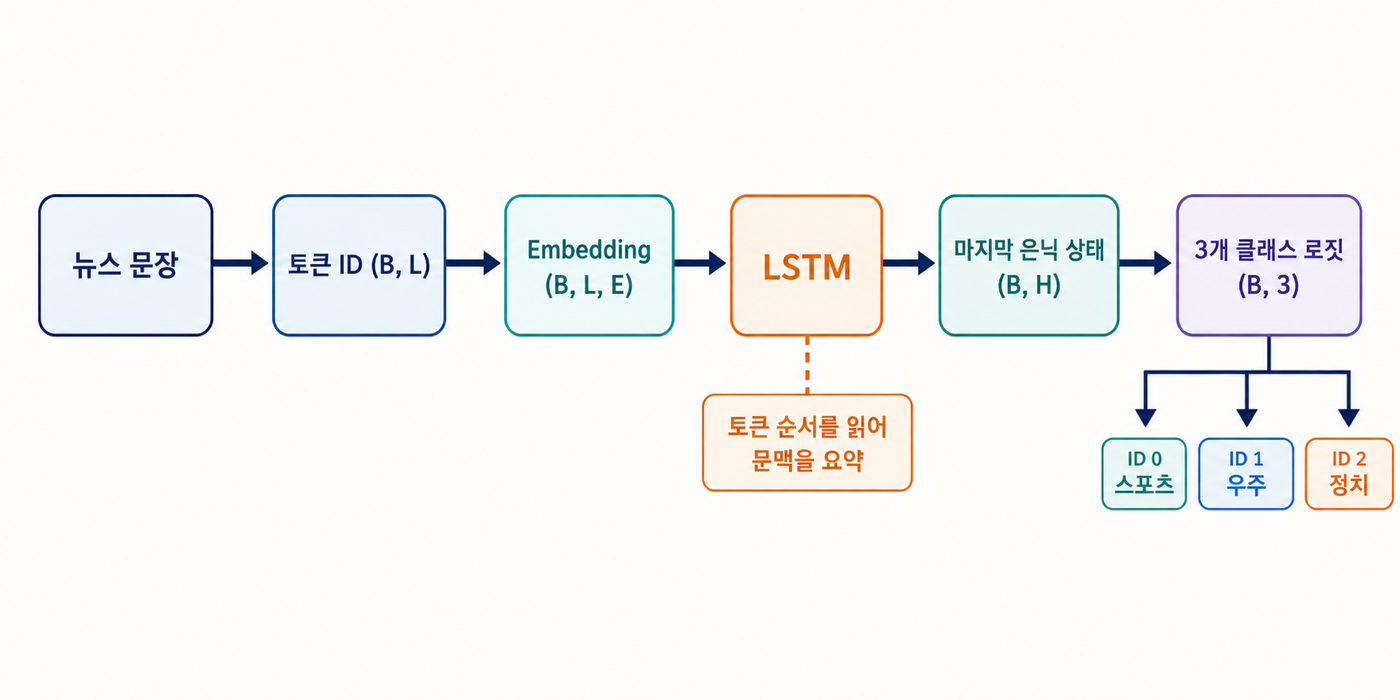


### 재현 가능한 환경과 데이터 준비

난수 seed를 고정하면 데이터 분할과 초기 가중치가 반복 실행에서 최대한 같아진다. 20 Newsgroups에서 하키·우주·정치 문서만 불러오고, 공식 테스트 세트는 마지막 평가에만 사용한다.


In [11]:
import copy
import random
import re
from collections import Counter
from importlib.metadata import version

import numpy as np
import torch
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import CrossEntropyLoss
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


categories = ["rec.sport.hockey", "sci.space", "talk.politics.misc"]

news_train_all = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
)
news_test = fetch_20newsgroups(
    subset="test",
    categories=categories,
    remove=("headers", "footers", "quotes"),
)

# stratify로 클래스 비율을 유지하며 학습·검증 데이터를 나눈다.
train_texts, validation_texts, train_labels, validation_labels = train_test_split(
    news_train_all.data,
    news_train_all.target,
    test_size=0.2,
    random_state=SEED,
    stratify=news_train_all.target,
)

print("Python 환경의 PyTorch:", version("torch"))
print("클래스 ID:", list(enumerate(news_train_all.target_names)))
print(
    "문서 수:",
    f"train={len(train_texts)}, validation={len(validation_texts)}, test={len(news_test.data)}",
)



Python 환경의 PyTorch: 2.13.0
클래스 ID: [(0, 'rec.sport.hockey'), (1, 'sci.space'), (2, 'talk.politics.misc')]
문서 수: train=1326, validation=332, test=1103


### 학습 문서로만 어휘를 만들고 토큰 ID로 변환

정규표현식으로 영문 단어를 소문자 토큰으로 만든다. 어휘 사전은 학습 문서에서만 만들며 `0`은 패딩, `1`은 학습 때 보지 못한 단어인 OOV에 예약한다.

각 문장은 최대 120개 토큰만 사용하고 짧은 문장의 뒤에는 PAD를 채운다. 결과 shape `(문장 수, 120)`에서 한 행은 한 뉴스 문서이고 한 열은 토큰 위치이다.


In [12]:
TOKEN_PATTERN = re.compile(r"[A-Za-z']+")  # 토큰화 진행 시 영단어만 남김

MAX_VOCAB_SIZE = 6_000  # 사전에 등록되는 최대 토큰 수

MAX_LENGTH = 120  #한 뉴스 문장에 사용되는 최대 토큰 수 [길면 자르기, 모자르면 PAD 채우기]

# 전달받은 뉴스 문장을 영단어 목록으로 변환(토큰화)
def tokenize(text):
    """영문 문자열을 소문자로 바꾼 뒤 순서가 유지된 토큰 문자열 목록을 반환한다."""
    return TOKEN_PATTERN.findall(text.lower())


# 학습 문서에서만 토큰 빈도를 세어 평가 정보 유입을 막는다.
token_counts = Counter(
    token
    for text in train_texts
    for token in tokenize(text)
)

# 어휘 사전 제일 앞 2개를 미리 지정
vocabulary = {"<PAD>": 0, "<OOV>": 1}
for token, _ in token_counts.most_common(MAX_VOCAB_SIZE - 2):
    vocabulary[token] = len(vocabulary)

# 전달 받은 토큰화된 뉴스 문장을 토큰 ID 목록으로 변환
def encode_texts(texts):
    """문장 목록을 `(문장 수, 120)` shape의 torch.long 토큰 ID 텐서로 변환한다."""
    encoded_rows = []

    for text in texts:
        # 토큰을 최대 길이까지 자르고 미등록 토큰은 OOV ID로 바꾼다.
        token_ids = [
            vocabulary.get(token, vocabulary["<OOV>"])
            for token in tokenize(text)[:MAX_LENGTH]
        ]

        # 오른쪽에 PAD ID를 채워 모든 문장 길이를 120으로 맞춘다.
        padding_size = MAX_LENGTH - len(token_ids)
        encoded_rows.append(token_ids + [vocabulary["<PAD>"]] * padding_size)

    # Embedding 입력이 되도록 문장별 ID를 long 텐서로 쌓는다.
    return torch.tensor(encoded_rows, dtype=torch.long)

# 토큰 ID 목록으로 변환하는 함수를 이용해서 학습, 검증, 평가 데이터를 모두 토큰 ID 목록화
X_train = encode_texts(train_texts)
X_validation = encode_texts(validation_texts)
X_test = encode_texts(news_test.data)
y_train = torch.tensor(train_labels, dtype=torch.long)
y_validation = torch.tensor(validation_labels, dtype=torch.long)
y_test = torch.tensor(news_test.target, dtype=torch.long)

print("어휘 크기:", len(vocabulary))
print("train 입력 shape:", tuple(X_train.shape))
# PAD가 아닌 위치의 합이 첫 문서의 실제 토큰 길이이다.
print("첫 문서의 실제 토큰 수:", int((X_train[0] != 0).sum()))
print("첫 문서 앞쪽 ID:", X_train[0, :12].tolist())



어휘 크기: 6000
train 입력 shape: (1326, 120)
첫 문서의 실제 토큰 수: 120
첫 문서 앞쪽 ID: [397, 423, 676, 1618, 398, 1853, 1, 27, 313, 457, 1, 27]


### 배치 구성과 LSTM 분류기 정의

`DataLoader`는 여러 문서를 한 배치로 묶는다. 입력 shape는 `(B, L)`이고 모델 안에서 임베딩을 거치면 `(B, L, E)`가 된다.

패딩된 마지막 위치를 그대로 LSTM에 넣고 `output[:, -1]`을 사용하면 실제 문장보다 PAD를 더 많이 읽은 결과가 된다. `pack_padded_sequence()`는 문장별 실제 길이까지만 LSTM이 처리하도록 하며, 반환된 `hidden[-1]`을 문장 요약으로 사용할 수 있다.


In [13]:
BATCH_SIZE = 64 # 모델에 한 번에 전달할 배치(뉴스) 수
EMBEDDING_DIM = 48 # 토큰 ID 1개가 48차원의 임베딩 벡터로 변환
HIDDEN_DIM = 64 # 문장(뉴스) 하나를 요약한 hidden state의 특성(벡터) 수
NUM_CLASSES = len(news_train_all.target_names) # 정답 개수 == 로짓 개수

# 토큰 ID와 정답을 묶어 미니배치 단위로 읽는다.
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    TensorDataset(X_validation, y_validation),
    batch_size=128,
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=128,
)

# LSTM 기반 뉴스 분류 모델 생성
class NewsLSTMClassifier(nn.Module):
    """`(B, L)` 토큰 ID를 받아 `(B, C)` 뉴스 주제 로짓을 반환한다."""

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()

        # 임베딩은 토큰 ID를 벡터로, LSTM은 순서를 문맥으로 바꾼다.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0,
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim, # 48
            hidden_size=hidden_dim, # 64
            batch_first=True,
        )
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids):
        # 입력 (B, L)을 임베딩 (B, L, E)로 변환한다.
        embedded = self.embedding(input_ids)

        # PAD를 제외한 길이를 배치의 각 문장마다 계산한다.
        lengths = (input_ids != 0).sum(dim=1).clamp(min=1).cpu()
        # 실제 토큰 길이까지만 처리하도록 패딩된 배치를 압축한다.
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        # 마지막 LSTM 층의 은닉 상태를 문장 벡터로 사용한다.
        _, (hidden, _) = self.lstm(packed)
        sentence_vectors = hidden[-1]
        return self.classifier(sentence_vectors)   # logits 3개 반환


### 모델 생성과 출력 shape 확인

앞에서 정의한 `NewsLSTMClassifier`를 실제 객체로 만들고 첫 학습 배치를 통과시킨다. 입력 `(64, 120)`은 문서 64개와 문서당 토큰 위치 120개를 뜻하며, 출력 `(64, 3)`은 문서마다 세 뉴스 클래스의 로짓을 하나씩 계산했다는 뜻이다.

이 단계에서는 학습하지 않고 `torch.no_grad()`로 입출력 구조만 확인한다. 여기서 만든 `model`과 `(B, 3)` 로짓 구조는 다음 셀의 손실 계산과 가중치 학습에 그대로 사용된다.


In [14]:
model = NewsLSTMClassifier(
    vocab_size=len(vocabulary),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
)

sample_inputs, _ = next(iter(train_loader))
# 학습 없이 (B, L) 입력이 (B, C) 로짓으로 바뀌는지만 확인한다.
with torch.no_grad():
    sample_logits = model(sample_inputs)

print("배치 토큰 ID shape:", tuple(sample_inputs.shape))
print("배치 클래스 로짓 shape:", tuple(sample_logits.shape))



배치 토큰 ID shape: (64, 120)
배치 클래스 로짓 shape: (64, 3)


### 손실을 줄이며 실제로 모델 학습

`CrossEntropyLoss`는 `(B, 3)` 로짓과 `(B,)` 정답 클래스 ID를 비교한다. 내부에서 소프트맥스에 해당하는 계산을 안정적으로 처리하므로 모델의 `forward()`에서 소프트맥스를 먼저 적용하지 않는다.

각 epoch마다 학습 손실과 검증 손실·macro F1을 계산한다. 검증 손실이 가장 낮은 시점의 가중치를 복사해 두었다가 학습이 끝난 뒤 복원하므로 마지막 epoch가 과적합되더라도 더 나은 상태를 사용할 수 있다.

다음 빈 코드셀을 비운 채 뒤의 평가 셀을 실행하면 초기화된 미학습 모델의 점수가 출력될 수 있다. LSTM 학습과 최적 검증 가중치 복원을 완성한 뒤 테스트 평가를 실행한다.

In [17]:
# 손실 함수 생성
criterion = nn.CrossEntropyLoss()  # 활성화함수로 Softmax 내장하고 있음

# 최적화
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

EPOCHS = 6

# 첫 epoch는 어떤 유한 손실보다도 개선으로 판정되도록 양의 무한대로 시작한다.
best_validation_loss = float("inf")
best_state = None

history = []

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_loss_sum = 0.0

    for batch_inputs, batch_labels in train_loader:
        batch_inputs = batch_inputs
        batch_labels = batch_labels

        optimizer.zero_grad()

        logits = model(batch_inputs)
        loss = criterion(logits, batch_labels)

        loss.backward()
        optimizer.step()
        # loss.item()은 배치 평균이므로 실제 배치 크기를 곱해 epoch 전체 손실 합으로 누적한다.
        train_loss_sum += loss.item() * batch_labels.size(0)

    # eval 모드
    model.eval()
    validation_loss_sum = 0.0
    validation_predictions = []
    validation_answers = []

    with torch.no_grad():
        for batch_inputs, batch_labels in validation_loader:
            batch_inputs = batch_inputs
            batch_labels = batch_labels
            validation_logits = model(batch_inputs)
            validation_loss_sum += (
                criterion(validation_logits, batch_labels).item()
                * batch_labels.size(0)
            )

            validation_predictions.extend(
                validation_logits.argmax(dim=1).cpu().tolist()
            )
            validation_answers.extend(batch_labels.cpu().tolist())



    train_loss = train_loss_sum / len(train_loader.dataset)
    validation_loss = validation_loss_sum / len(validation_loader.dataset)
    validation_macro_f1 = f1_score(
        validation_answers,
        validation_predictions,
        average="macro",
    )
    history.append((train_loss, validation_loss, validation_macro_f1))

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | "
        f"validation loss {validation_loss:.4f} | "
        f"validation macro F1 {validation_macro_f1:.4f}"
    )

# 테스트는 마지막 epoch가 아니라 validation 손실이 가장 낮았던 가중치로 수행한다.
_ = model.load_state_dict(best_state)

# 연속 두 epoch를 비교해 train 손실은 감소했지만 validation 손실은 증가한 시점을 과적합 후보로 모은다.
overfitting_signal_epochs = [
    epoch_index + 1
    for epoch_index in range(1, len(history))
    if history[epoch_index][0] < history[epoch_index - 1][0]
    and history[epoch_index][1] > history[epoch_index - 1][1]
]
if overfitting_signal_epochs:
    print("과적합 신호가 나타난 epoch:", overfitting_signal_epochs)
else:
    print("이번 6 epoch에서는 검증 손실 증가에 따른 뚜렷한 과적합 신호가 없다.")


epoch 01 | train loss 0.5935 | validation loss 0.8530 | validation macro F1 0.5958
epoch 02 | train loss 0.4733 | validation loss 0.8328 | validation macro F1 0.6079
epoch 03 | train loss 0.3794 | validation loss 0.7960 | validation macro F1 0.6625
epoch 04 | train loss 0.2943 | validation loss 0.8100 | validation macro F1 0.6369
epoch 05 | train loss 0.2733 | validation loss 0.7898 | validation macro F1 0.6161
epoch 06 | train loss 0.2291 | validation loss 0.9130 | validation macro F1 0.6569
과적합 신호가 나타난 epoch: [4, 6]


### 기준선, 테스트 성능과 실제 예측 해석

최빈 클래스 기준선은 문장 내용을 보지 않고 학습 데이터에서 가장 많은 클래스만 고른다. LSTM의 accuracy와 macro F1이 이 값을 넘는지 확인해야 토큰 순서를 학습한 모델을 사용할 근거가 생긴다.

소프트맥스 확률은 세 클래스 로짓을 합이 1인 값으로 바꾼 것이다. 오분류 사례에서는 본문이 비어 있거나 여러 주제를 함께 포함하는지, OOV와 잘림이 많았는지를 함께 살펴본다.


In [18]:
# 최빈 클래스를 반복해 문서 내용을 보지 않는 기준선을 만든다.
majority_class = Counter(train_labels).most_common(1)[0][0]
baseline_predictions = np.full(len(news_test.target), majority_class)

model.eval()
test_logits_batches = []
test_predictions = []

# 평가에서는 기울기를 저장하지 않고 배치별 로짓을 모은다.
with torch.no_grad():
    for batch_inputs, _ in test_loader:
        logits = model(batch_inputs)
        test_logits_batches.append(logits.cpu())
        # 각 로짓 행에서 가장 큰 클래스 열을 예측 ID로 고른다.
        test_predictions.extend(logits.argmax(dim=1).cpu().tolist())

# 배치 로짓을 이어 붙이고 클래스 축 softmax로 확률을 만든다.
test_logits = torch.cat(test_logits_batches)
test_probabilities = torch.softmax(test_logits, dim=1)
test_predictions = np.array(test_predictions)

baseline_accuracy = accuracy_score(news_test.target, baseline_predictions)
# macro F1은 세 클래스의 F1을 같은 비중으로 평균한다.
baseline_macro_f1 = f1_score(
    news_test.target,
    baseline_predictions,
    average="macro",
)
lstm_accuracy = accuracy_score(news_test.target, test_predictions)
lstm_macro_f1 = f1_score(
    news_test.target,
    test_predictions,
    average="macro",
)

print(f"최빈 클래스 기준선 accuracy: {baseline_accuracy:.3f}")
print(f"최빈 클래스 기준선 macro F1: {baseline_macro_f1:.3f}")
print(f"LSTM test accuracy: {lstm_accuracy:.3f}")
print(f"LSTM test macro F1: {lstm_macro_f1:.3f}")
print()
print(
    classification_report(
        news_test.target,
        test_predictions,
        target_names=news_train_all.target_names,
        digits=3,
    )
)

# 예측과 정답의 일치 여부로 오분류와 정분류 행을 나눈다.
wrong_indices = np.flatnonzero(test_predictions != news_test.target)
correct_indices = np.flatnonzero(test_predictions == news_test.target)
print(f"오분류 문서 수: {len(wrong_indices)} / {len(news_test.target)}")

probability_example_indices = [correct_indices[0], wrong_indices[0]]
print()
print("예문별 3개 클래스 확률:")
for index in probability_example_indices:
    # 확률 행의 열을 클래스 이름과 같은 순서로 연결한다.
    probability_by_class = {
        class_name: round(float(probability), 3)
        for class_name, probability in zip(
            news_train_all.target_names,
            test_probabilities[index],
        )
    }
    actual = news_train_all.target_names[news_test.target[index]]
    predicted = news_train_all.target_names[test_predictions[index]]
    print(f"  정답={actual} / 예측={predicted} / 확률={probability_by_class}")

for index in wrong_indices[:3]:
    preview = " ".join(news_test.data[index].split())[:220]
    actual = news_train_all.target_names[news_test.target[index]]
    predicted = news_train_all.target_names[test_predictions[index]]
    # 가장 큰 클래스 확률을 해당 예측의 신뢰도로 읽는다.
    confidence = float(test_probabilities[index].max())
    print()
    print(f"정답={actual} / 예측={predicted} / 최고확률={confidence:.3f}")
    print("본문:", preview)



최빈 클래스 기준선 accuracy: 0.362
최빈 클래스 기준선 macro F1: 0.177
LSTM test accuracy: 0.634
LSTM test macro F1: 0.622

                    precision    recall  f1-score   support

  rec.sport.hockey      0.719     0.769     0.743       399
         sci.space      0.641     0.607     0.623       394
talk.politics.misc      0.505     0.494     0.499       310

          accuracy                          0.634      1103
         macro avg      0.622     0.623     0.622      1103
      weighted avg      0.631     0.634     0.632      1103

오분류 문서 수: 404 / 1103

예문별 3개 클래스 확률:
  정답=talk.politics.misc / 예측=talk.politics.misc / 확률={'rec.sport.hockey': 0.028, 'sci.space': 0.183, 'talk.politics.misc': 0.789}
  정답=sci.space / 예측=rec.sport.hockey / 확률={'rec.sport.hockey': 0.738, 'sci.space': 0.09, 'talk.politics.misc': 0.172}

정답=sci.space / 예측=rec.sport.hockey / 최고확률=0.738
본문: Using greenhouses to extend the growing season shouldn't be a problem. I'm supprised they don't do so in Alaska (cheaper to import, 

## 정리와 한계

이번 모델은 `토큰 ID → 임베딩 → LSTM 최종 은닉 상태 → 클래스 로짓`의 흐름을 실제 학습과 평가로 연결한다. 모델을 정의한 직후의 로짓은 임의 초기 가중치가 만든 값이지만, `loss.backward()`와 `optimizer.step()`을 반복한 뒤의 로짓은 뉴스 주제 정답을 더 잘 맞히도록 수정된 가중치가 만든 값이다.

문서를 120개 토큰으로 자르므로 뒤쪽 정보가 사라질 수 있고, 6 epoch의 작은 CPU 모델은 최고 성능을 목표로 하지 않는다. 중요한 결과는 shape 하나가 아니라 기준선보다 나아졌는지, 검증과 테스트 지표가 어떻게 다른지, 어떤 문서를 왜 틀렸는지 설명할 수 있는가이다.
